In [7]:
import re
from difflib import SequenceMatcher

def clean_seq(s: str) -> str:
    # keep letters only (A-Z), drop spaces, numbers, >headers, etc.
    s = s.upper()
    s = re.sub(r"[^A-Z]", "", s)
    return s

def debug_substring_search(wt_seq: str, epitope: str, k: int = 10):
    wt_raw = wt_seq
    ep_raw = epitope

    wt = clean_seq(wt_seq)
    ep = clean_seq(epitope)

    print("Raw lengths:", len(wt_raw), len(ep_raw))
    print("Clean lengths:", len(wt), len(ep))
    print("Epitope:", ep)

    idx = wt.find(ep)
    if idx != -1:
        print(f"✅ Exact match found at 1-based position {idx+1}")
        return

    print("❌ Exact match NOT found.")
    print("Checking if epitope contains non-standard letters:",
          [c for c in set(ep) if c not in set("ACDEFGHIKLMNPQRSTVWY")])

    # Near-match scan: find the most similar window of same length
    L = len(ep)
    best = (-1, -1.0, "")
    for i in range(0, len(wt) - L + 1):
        window = wt[i:i+L]
        score = SequenceMatcher(None, window, ep).ratio()
        if score > best[1]:
            best = (i, score, window)

    best_i, best_score, best_window = best
    print(f"Best near-match window at 1-based position {best_i+1}")
    print("WT window :", best_window)
    print("Similarity:", round(best_score, 3))

    # show mismatches
    mismatches = [(j+1, best_window[j], ep[j]) for j in range(L) if best_window[j] != ep[j]]
    print("Mismatches (pos_in_epitope, wt_res, ep_res):", mismatches[:k], ("..." if len(mismatches) > k else ""))




Raw lengths: 281 10
Clean lengths: 281 10
Epitope: QLIPCMDVVL
❌ Exact match NOT found.
Checking if epitope contains non-standard letters: []
Best near-match window at 1-based position 115
WT window : QLIPCRDVVL
Similarity: 0.9
Mismatches (pos_in_epitope, wt_res, ep_res): [(6, 'R', 'M')] 


In [101]:
# Example usage:
wt_seqs = ["VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFPPQQPYPQPQPFLPQLPYPQPQPFPPQQSYPQPQPQYPQPQQPISQQQAQLQQQQQQQQQQILQQILQQQLIPCRDVVLQQPNIAHASSQVSQQSYQLLQQLCCQQLWQTPEQSRCQAIHNVIHAIILHHQQQQQQQQQQQQQQQQQQQQQQQQQQQQPSSQVSYQQPQQQYPSGQGSFQPSQQNPQAQGFVQPQQLPQFEEIRNLALQTLPAMCNVYIPPYCSTTIAPFGIFSTN",
           'MKTFIIFVLLAMAMNIASASRLLSPRGKELHTPQEQFPQQQQFPQPQQFPQQQIPQQHQIPQQPQQFPQQQQFLQQQQIPQQQIPQQHQIPQQPQQFPQQQQFPQQHQSPQQQFPQQQFPQQKLPQQEFPQQQISQQPQQLPQQQQIPQQPQQFLQQQQFPQQQPPQQHQFPQQQLPQQQQIPQQQQIPQQPQQIPQQQQIPQQPQQFPQQQFPQQQFPQQQFPQQEFPQQQQFPQQQIARQPQQLPQQQQIPQQPQQFPQQQQFPQQQSPQQQQFPQQQFPQQQQLPQKQFPQPQQIPQQQQIPQQPQQFPQQQFPQQQQFPQQQEFPQQQFPQQQFHQQQLPQQQFPQQQFPQQQFPQQQQFPQQQQLTQQQFPRPQQSPEQQQFPQQQFPQQPPQQFPQQQFPIPYPPQQSEEPSPYQQYPQQQPSGSDVISISGL',
          ]
epitopes = ["QLIPCMDVVL", 'AMAMKIATA']

for i in range(len(wt_seqs)):
    
    debug_substring_search(wt_seqs[i], epitopes[i])

Raw lengths: 281 10
Clean lengths: 281 10
Epitope: QLIPCMDVVL
❌ Exact match NOT found.
Checking if epitope contains non-standard letters: []
Best near-match window at 1-based position 115
WT window : QLIPCRDVVL
Similarity: 0.9
Mismatches (pos_in_epitope, wt_res, ep_res): [(6, 'R', 'M')] 
Raw lengths: 439 9
Clean lengths: 439 9
Epitope: AMAMKIATA
❌ Exact match NOT found.
Checking if epitope contains non-standard letters: []
Best near-match window at 1-based position 11
WT window : AMAMNIASA
Similarity: 0.778
Mismatches (pos_in_epitope, wt_res, ep_res): [(5, 'N', 'K'), (8, 'S', 'T')] 


In [78]:
wt_sequence[110:130]

'ILQQQLIPCRDVVLQQPNIA'

In [8]:
AA20 = "ACDEFGHIKLMNPQRSTVWY"

def mutate_window_positions(wt_seq: str, start_1based: int, window_len: int, aa_alphabet: str = AA20):
    """
    Mutate every position in wt_seq within the window [start_1based, start_1based+window_len-1].
    Returns (mutation_label, mutant_sequence).
    """
    wt_seq = wt_seq.upper().strip()
    start0 = start_1based - 1
    end0 = start0 + window_len

    if start0 < 0 or end0 > len(wt_seq):
        raise ValueError("Window out of range.")

    mutants = []
    for abs_index in range(start0, end0):
        wt_res = wt_seq[abs_index]
        pos_1based = abs_index + 1

        for aa in aa_alphabet:
            if aa == wt_res:
                continue
            mut_seq = wt_seq[:abs_index] + aa + wt_seq[abs_index+1:]
            label = f"{wt_res}{pos_1based}{aa}"
            mutants.append((label, mut_seq))
    return mutants

# Your case: best window begins at 115 and length is 10
mutants = mutate_window_positions(wt_sequence, start_1based=115, window_len=10)

In [9]:
len(mutants)

190

In [13]:
import torch
import esm
import torch.nn as nn

DEVICE = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")

# --- paste your DDGPredictor class definition here exactly as in training ---

class DDGPredictor(nn.Module):
    def __init__(self, esm_model, alphabet, hidden=256, dropout=0.2):
        super().__init__()
        self.esm, self.alphabet = esm_model, alphabet
        self.repr_layer = esm_model.num_layers # extract representations from the last layer
        d = esm_model.embed_dim # d: per-token embedding dimension; for esm2_t6_8M_UR50D, d=320
        self.head = nn.Sequential( # simple MLP head that takes "engineered paired features" (concatenated pooled representations) to map to ΔΔG
            nn.LayerNorm(4*d), # Input diemnsions: (B,4*d). Normalizes the input features across the last dimension, because the four ESM representations can have different scales (like m*w is different than m-w) and LayerNorm can help stabilize training.
            nn.Linear(4*d, hidden), nn.GELU(), nn.Dropout(dropout), # fully connected layer, learning a weighted combination of the concatenated features, with GELU non-linear activation function and dropout (randomly zero some hidden neurons during training with the probability 0.2) for regularization
            nn.Linear(hidden, 1), # final linear layer that maps the hidden representation to a single scalar output (the predicted ΔΔG)
        )

    def encode(self, tokens): # encode a batch of tokenized sequences into pooled representations by averaging the per-token embeddings (ignoring padding and EOS tokens)
        h = self.esm(tokens, repr_layers=[self.repr_layer], return_contacts=False) # h: dictionary with keys "representations" and "contacts"; we only care about the representations, which is a list of length num_layers, where each element is a tensor of shape [B, L, d] (batch size, sequence length, embedding dimension)
        h = h["representations"][self.repr_layer] # h: tensor of shape [B, L, d] containing the per-token embeddings from the last layer of the ESM model
        mask = (tokens != self.alphabet.padding_idx) & (tokens != self.alphabet.eos_idx) # Sequences vary strongly in length. Short sequences were padded to the length of the longest on ein the batch, because matrix multiplication requires fixed shapes. mask: boolean tensor of shape [B, L] where True indicates valid tokens (not padding or EOS) and False indicates invalid tokens; this is used to mask out the padding and EOS tokens when averaging the embeddings.
        mask[:, 0] = False # also ignore the CLS token at the beginning of the sequence, which is not a real amino acid and can have a different embedding distribution than the other tokens. (: -> all rows, 0 -> first column)
        return (h * mask.unsqueeze(-1).float()).sum(1) / mask.sum(1, keepdim=True).float() # mask.unsqueeze(-1) changes shape from [B, L] to [B, L, 1],expanding the mask to apply across all "d" embedding dimensions;  ".float" converts boolean mask to 0/1 for multiplication;  "h * mask" : All "masked = false" tokens get automatically embedding = 0; ".sum(1)" summing all token embeddings within each protein, collapsing [B, L, d] to [B, d], which is the average embedding for each sequence in the batch, where the average is taken over the valid tokens (ignoring padding, EOS, and CLS)

    def forward(self, wt, mut): # 
        w, m = self.encode(wt), self.encode(mut) # each sequence is passed independently through the shared ESM encoder to get their pooled representations w and m, each of shape [B, d] --> Siamese architecture: the same ESM encoder processes both the wild-type and mutant sequences, allowing it to learn a shared representation space for both types of inputs, which can help the model learn how mutations affect the protein's properties by comparing their embeddings.
        return self.head(torch.cat([w, m, m-w, m*w], dim=-1)).squeeze(-1)

def load_ddg_model(ckpt_path: str):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    cfg = ckpt.get("cfg", {})

    # Must match training backbone
    esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()

    # Recreate predictor (same defaults hidden=256, dropout=0.2 unless you changed them)
    model = DDGPredictor(esm_model, alphabet).to(DEVICE)

    # Load weights (your checkpoint stores "model_state")
    model.load_state_dict(ckpt["model_state"], strict=True)

    model.eval()
    return model, alphabet, cfg

# Example
ckpt_path = "/home/course/Data/ddg_best_20260227_142913.ptrom"
model, alphabet, cfg = load_ddg_model(ckpt_path)
batch_converter = alphabet.get_batch_converter()

In [14]:
import numpy as np
from tqdm.auto import tqdm

def predict_ddg_for_mutants(
    model,
    alphabet,
    wt_seq: str,
    mutants,                # list of (label, mut_seq)
    batch_size: int = 32
):
    batch_converter = alphabet.get_batch_converter()
    wt_seq = wt_seq.upper().strip()

    results = []
    model.eval()

    for i in tqdm(range(0, len(mutants), batch_size), desc="Predicting"):
        chunk = mutants[i:i+batch_size]
        labels = [lab for lab, _ in chunk]
        mut_seqs = [seq.upper().strip() for _, seq in chunk]

        # tokenize WT batch and MUT batch
        wt_data  = list(zip(labels, [wt_seq] * len(chunk)))
        mut_data = list(zip(labels, mut_seqs))

        _, _, wt_tok  = batch_converter(wt_data)
        _, _, mut_tok = batch_converter(mut_data)

        wt_tok = wt_tok.to(DEVICE)
        mut_tok = mut_tok.to(DEVICE)

        with torch.no_grad():
            pred = model(wt_tok, mut_tok).detach().cpu().numpy()  # [B]

        results.extend(list(zip(labels, mut_seqs, pred.tolist())))

    return results

In [16]:
import pandas as pd

pred_rows = predict_ddg_for_mutants(model, alphabet, wt_sequence, mutants, batch_size=32)

df_pred = pd.DataFrame(pred_rows, columns=["mutation", "mut_sequence", "pred_ddG"])
df_pred = df_pred.sort_values("pred_ddG")  # most stabilizing first if negative = stabilizing
df_pred.head(20)

Predicting:   0%|          | 0/6 [00:00<?, ?it/s]

,mutation,mut_sequence,pred_ddG
39,I117C,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.622949
55,I117W,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.561218
115,D121C,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.560275
153,V123C,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.540296
58,P118C,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.539169
1,Q115C,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.508221
169,V123W,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.507519
172,L124C,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.506635
44,I117H,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.505632
131,D121W,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.502545


In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

AA20 = list("ACDEFGHIKLMNPQRSTVWY")

def plot_ddg_heatmap(df, start_pos):
    """
    df must have columns:
    - mutation (e.g. R115A)
    - pred_ddG
    """

    # extract position and mutant AA
    df["pos"] = df["mutation"].str.extract(r"(\d+)").astype(int)
    df["mut_aa"] = df["mutation"].str[-1]

    # pivot to matrix
    heat = df.pivot(index="mut_aa", columns="pos", values="pred_ddG")

    # reorder rows by AA20
    heat = heat.reindex(AA20)

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        heat,
        cmap="coolwarm",
        center=0,
        cbar_kws={"label": "Predicted ΔΔG"},
        linewidths=0.5
    )
    plt.title("Single Mutation ΔΔG Landscape")
    plt.xlabel("Position")
    plt.ylabel("Mutant Amino Acid")
    plt.tight_layout()
    plt.show()

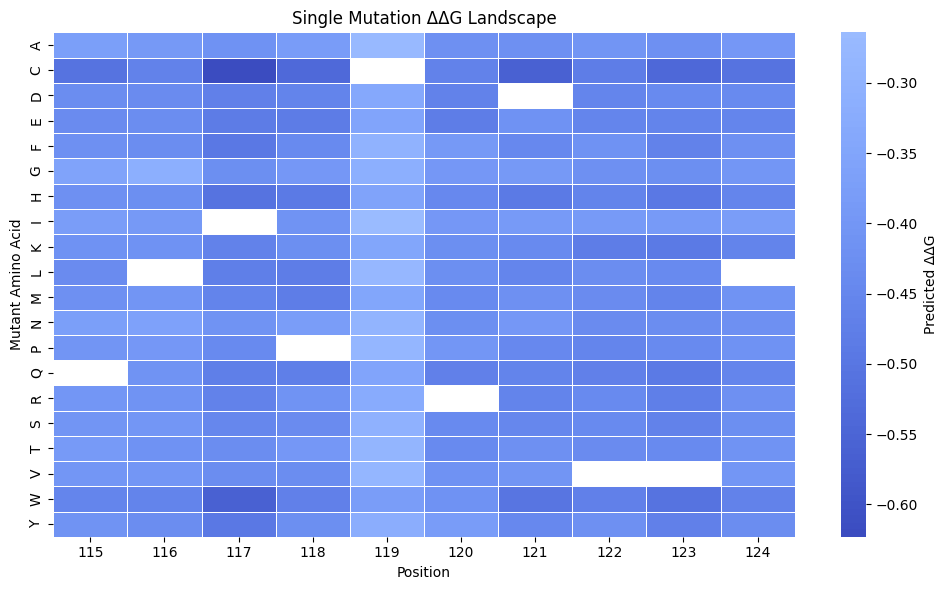

In [35]:
plot_ddg_heatmap(df_pred, 115)

In [55]:
def plot_position_sensitivity(df):
    df["pos"] = df["mutation"].str.extract(r"(\d+)").astype(int)

    pos_effect = (
        df.groupby("pos")["pred_ddG"].apply(lambda x: np.mean(x))
        # .apply(lambda x: np.mean(np.abs(x)))
        
    )

    plt.figure(figsize=(6, 4))
    plt.bar(pos_effect.index, pos_effect.values)
    positions = sorted(df["pos"].unique())

    plt.xticks(
        ticks=pos_effect.index,
        labels=pos_effect.index,
        rotation=0
    )
    plt.xlabel("Position")
    plt.ylabel("Mean ΔΔG")
    plt.title("Positional Sensitivity")
    plt.show()

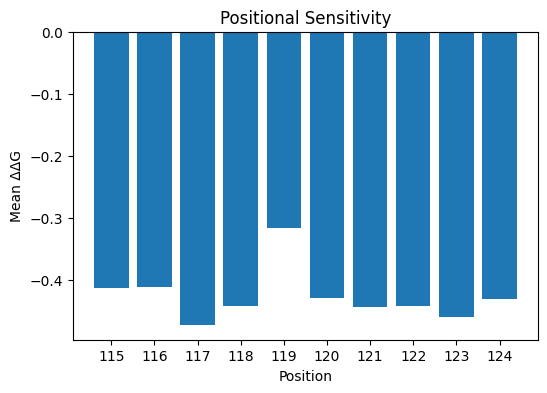

In [56]:
plot_position_sensitivity(df_pred)

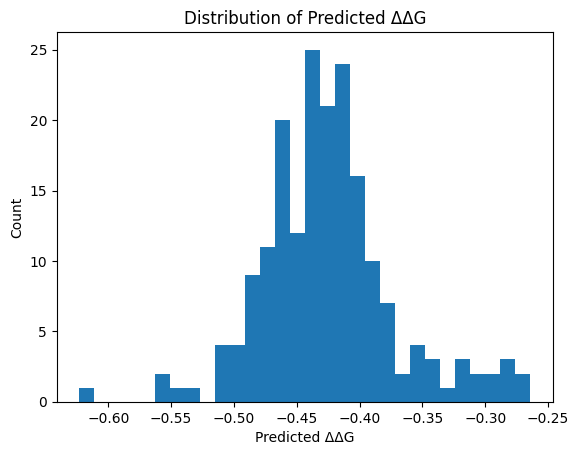

In [51]:
plt.hist(df_pred["pred_ddG"], bins=30)
# plt.axvline(0, color="k", linestyle="--")
plt.xlabel("Predicted ΔΔG")
plt.ylabel("Count")
plt.title("Distribution of Predicted ΔΔG")
plt.show()DME.md

In [89]:
pos117 = df_pred[df_pred["mutation"].str.contains("117")]
pos117 = pos117.copy()

pos117["wt_aa"] = pos117["mutation"].str[0]
pos117["mut_aa"] = pos117["mutation"].str[-1]

pos117.sort_values("pred_ddG")
pos117['mut_sequence'].iloc[0]

'VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFPPQQPYPQPQPFLPQLPYPQPQPFPPQQSYPQPQPQYPQPQQPISQQQAQLQQQQQQQQQQILQQILQQQLCPCRDVVLQQPNIAHASSQVSQQSYQLLQQLCCQQLWQTPEQSRCQAIHNVIHAIILHHQQQQQQQQQQQQQQQQQQQQQQQQQQQQPSSQVSYQQPQQQYPSGQGSFQPSQQNPQAQGFVQPQQLPQFEEIRNLALQTLPAMCNVYIPPYCSTTIAPFGIFSTN'

In [58]:
pos117["pred_ddG"].describe()

count    19.000000
mean     -0.472110
std       0.051350
min      -0.622949
25%      -0.488610
50%      -0.463956
75%      -0.436064
max      -0.410186
Name: pred_ddG, dtype: float64

In [59]:
wt117 = pos117["wt_aa"].iloc[0]
print("WT residue at 117:", wt117)

WT residue at 117: I


In [52]:
df_pred["wt_aa"] = df_pred["mutation"].str[0]
df_pred["mut_aa"] = df_pred["mutation"].str[-1]

df_pred["is_hydrophobic_change"] = (
    df_pred["wt_aa"].isin(list("AILMFWV")) &
    ~df_pred["mut_aa"].isin(list("AILMFWV"))
)

df_pred.groupby("is_hydrophobic_change")["pred_ddG"].mean()

is_hydrophobic_change
False   -0.414625
True    -0.447047
Name: pred_ddG, dtype: float64

In [79]:
# Your case: best window begins at 115 and length is 10
mutants_full_seq = mutate_window_positions(wt_sequence, start_1based=1, window_len=len(wt_sequence))

In [82]:
pred_rows_full = predict_ddg_for_mutants(
    model, alphabet, wt_sequence, mutants_full_seq, batch_size=32
)

df_pred_full = pd.DataFrame(
    pred_rows_full,
    columns=["mutation", "mut_sequence", "pred_ddG"]
)

df_pred_full = df_pred_full.sort_values("pred_ddG")  # negative = stabilizing

Predicting:   0%|          | 0/167 [00:00<?, ?it/s]

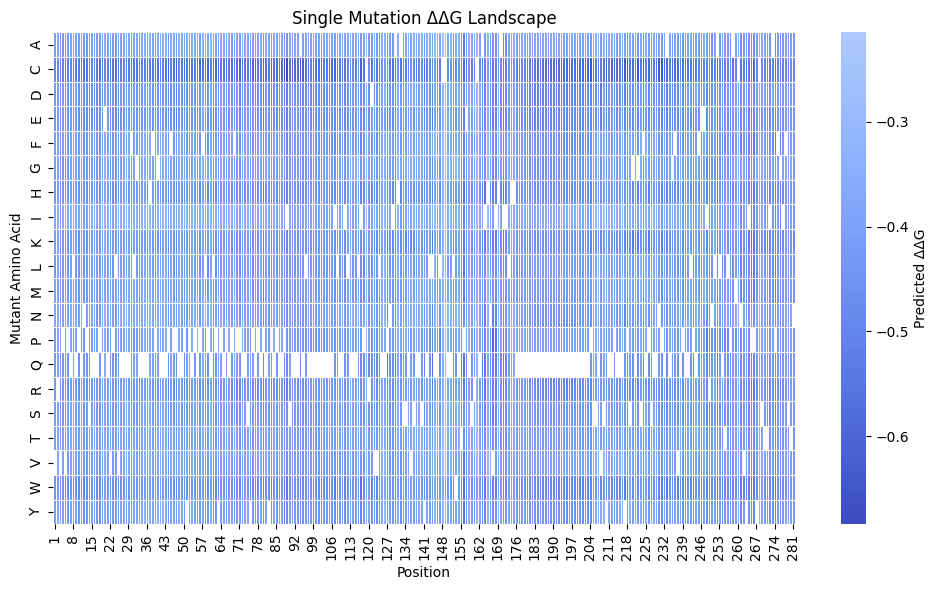

In [83]:
plot_ddg_heatmap(df_pred_full, 1)

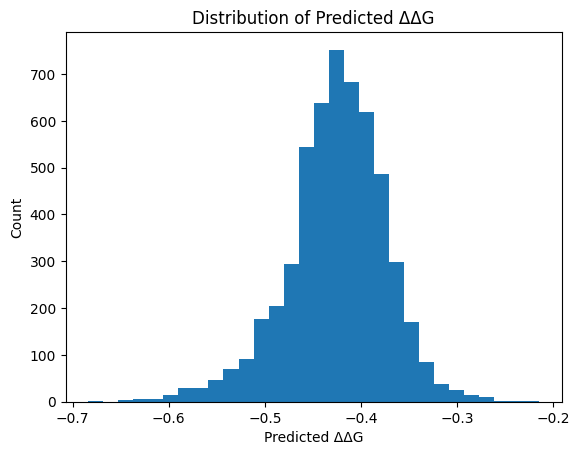

In [85]:
plt.hist(df_pred_full["pred_ddG"], bins=30)
# plt.axvline(0, color="k", linestyle="--")
plt.xlabel("Predicted ΔΔG")
plt.ylabel("Count")
plt.title("Distribution of Predicted ΔΔG")
plt.show()

In [90]:
df_pred_full

,mutation,mut_sequence,pred_ddG,pos,mut_aa
1673,I89C,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.683810,89,C
1654,P88C,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.671115,88,C
3858,P204C,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.651078,204,C
4371,P231C,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.641592,231,C
4200,G222C,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.637188,222,C
...,...,...,...,...,...
3959,S209I,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.262426,209,I
2826,C149S,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.248825,149,S
2827,C149T,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.246166,149,T
2812,C149A,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.234362,149,A


In [91]:
outside_positions = np.r_[1:115, 125:df_pred_full["pos"].max()+1]  # 1..114 and 125..maxpos
df_pred_outside_epi = df_pred_full[df_pred_full["pos"].isin(outside_positions)].copy()

epitope_positions = np.r_[115:125]  # 115..124
df_pred_epi = df_pred_full[df_pred_full["pos"].isin(epitope_positions)].copy()

In [92]:
df_pred_outside_epi

,mutation,mut_sequence,pred_ddG,pos,mut_aa
1673,I89C,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.683810,89,C
1654,P88C,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.671115,88,C
3858,P204C,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.651078,204,C
4371,P231C,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.641592,231,C
4200,G222C,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.637188,222,C
...,...,...,...,...,...
3959,S209I,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.262426,209,I
2826,C149S,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.248825,149,S
2827,C149T,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.246166,149,T
2812,C149A,VRVPVPQLQPQNPSQQQPQEQVPLVQQQQFLGQQQQHFPGQQQPFP...,-0.234362,149,A


In [93]:
df_pred_outside_epi['pred_ddG'].mean() - df_pred_epi['pred_ddG'].mean()

9.252637086459847e-05